<a href="https://colab.research.google.com/github/Alahin04/Actividad-An-lisis-Cambio-Clim-tico---Pr-ctica-SQL/blob/main/An%C3%A1lisis_Cambio_Clim%C3%A1tico_SQL_IMD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TRABAJO PRÁCTICO - ANÁLISIS DE TEMPERATURA GLOBAL CON SQL Y PYTHON**

---


**Curso:** Introducción a la Minería de Datos


---


**Estudiante:** Samuel Alahin López Cadavid


In [157]:
#Instalación e importación de librerías
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')
print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 1. Carga de datos
Se carga la base de datos GlobalLandTemperaturesByCountry.csv obtenida de Kaggle (Berkeley Earth),
que contiene registros mensuales de temperatura promedio por país desde 1743 hasta 2013.

In [158]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [159]:
df = pd.read_csv('/content/drive/MyDrive/GlobalLandTemperaturesByCountry.csv')
print(f"\n Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print("\n Primeras filas:")
df.head(10)


 Dimensiones: 577,462 filas × 4 columnas

 Primeras filas:


,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland
5,1744-04-01,1.530,4.680,Åland
6,1744-05-01,6.702,1.789,Åland
7,1744-06-01,11.609,1.577,Åland
8,1744-07-01,15.342,1.410,Åland
9,1744-08-01,NaN,NaN,Åland


In [160]:
print("EXPLORACIÓN INICIAL DEL DATASET")
#Tipos de datos
print("\n Tipos de datos:")
print(df.dtypes)

#Valores faltantes
print("\n Valores faltantes por columna:")
nulos = df.isnull().sum()
porcentaje = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Faltantes': nulos, 'Porcentaje (%)': porcentaje})
print(resumen_nulos)

#Número de países
print(f"\n Número de países: {df['Country'].nunique()}")

#Rango temporal (antes de convertir)
print(f"\n Fecha mínima: {df['dt'].min()}")
print(f"Fecha máxima: {df['dt'].max()}")

EXPLORACIÓN INICIAL DEL DATASET

 Tipos de datos:
dt                                object
AverageTemperature               float64
AverageTemperatureUncertainty    float64
Country                           object
dtype: object

 Valores faltantes por columna:
                               Faltantes  Porcentaje (%)
dt                                     0            0.00
AverageTemperature                 32651            5.65
AverageTemperatureUncertainty      31912            5.53
Country                                0            0.00

 Número de países: 243

 Fecha mínima: 1743-11-01
Fecha máxima: 2013-09-01


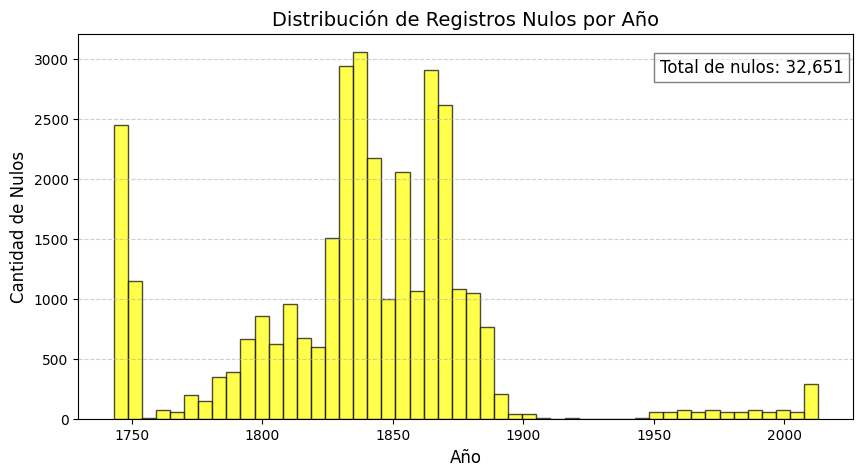

In [161]:
df['dt'] = pd.to_datetime(df['dt'])
#Datos faltantes para AverageTemperature
nulos_temp = df[df['AverageTemperature'].isnull()]

#histograma de nulos por año
plt.figure(figsize=(10, 5))
plt.hist(nulos_temp['dt'].dt.year, bins=50, color='yellow', edgecolor='black', alpha=0.7)
plt.title('Distribución de Registros Nulos por Año', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de Nulos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

#cantidad total de nulos/faltantes
total_nulos_uncertainty = len(nulos_temp)
plt.text(plt.xlim()[0] + (plt.xlim()[1] - plt.xlim()[0]) * 0.75,
         plt.ylim()[1] * 0.9,
         f'Total de nulos: {total_nulos_uncertainty:,}',
         fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

plt.show()

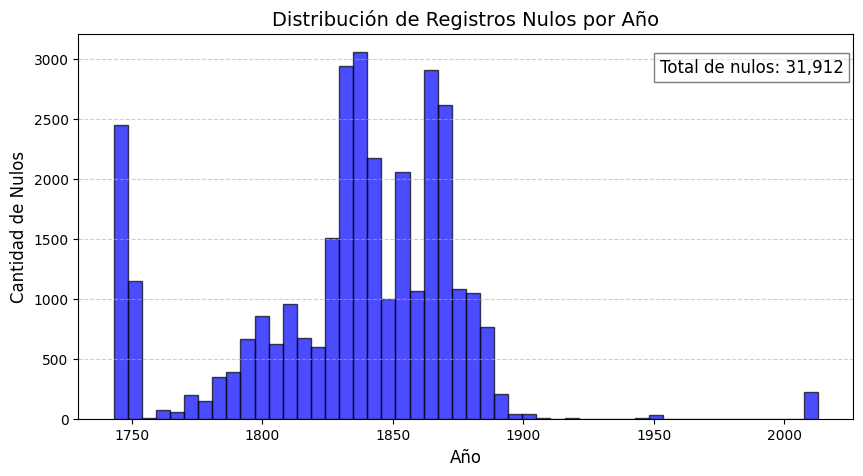

In [162]:
#Datos faltantes para AverageTemperatureUncertainty
nulos_temp = df[df['AverageTemperatureUncertainty'].isnull()]

#histograma de nulos por año
plt.figure(figsize=(10, 5))
plt.hist(nulos_temp['dt'].dt.year, bins=50, color='blue', edgecolor='black', alpha=0.7)
plt.title('Distribución de Registros Nulos por Año', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de Nulos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

#cantidad total de nulos/faltantes
total_nulos_uncertainty = len(nulos_temp)
plt.text(plt.xlim()[0] + (plt.xlim()[1] - plt.xlim()[0]) * 0.75,
         plt.ylim()[1] * 0.9,
         f'Total de nulos: {total_nulos_uncertainty:,}',
         fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

plt.show()

### **¿Por qué se eliminan estos registros?**

Tras analizar las gráficas de distribución de nulos, se procede a la eliminación de las filas vacías por tres razones clave:

*   **Falta de representatividad:** La mayoría de los nulos pertenecen al siglo XIX. Mantenerlos o intentar inventar esos valores (imputación) introduciría errores en el cálculo de promedios globales.
*   **Calidad de la fuente:** El histograma confirma que a partir de **1960** (periodo de interés), la base de datos es sólida y está completa.
*   **Precisión científica:** Al trabajar con **32,651** registros faltantes de temperatura, el borrado asegura que los resultados de las consultas SQL posteriores se basen únicamente en evidencias registradas y no en suposiciones.

## 2. Exploración inicial
La base contiene 577,462 registros de 243 países. Se identificaron 32,651 valores faltantes
en AverageTemperature (5.65%) y 31,912 en AverageTemperatureUncertainty (5.53%).
Estos registros serán eliminados para el análisis agregado por las tres razones claves que mencioné anteriomente.

In [163]:
#Transformación y limpieza
#Convertir 'dt' a tipo fecha
df['dt'] = pd.to_datetime(df['dt'])

#Extraer año
df['Year'] = df['dt'].dt.year

#Eliminar filas sin temperatura (para los cálculos agregados)
df_clean = df.dropna(subset=['AverageTemperature']).copy()
print(f" Limpieza completada")
print(f"   Registros originales : {len(df):,}")
print(f"   Registros sin nulos  : {len(df_clean):,}")
print(f"   Registros eliminados : {len(df) - len(df_clean):,}")
print(f"\n  Rango de años: {df_clean['Year'].min()} — {df_clean['Year'].max()}")
df_clean.head()

 Limpieza completada
   Registros originales : 577,462
   Registros sin nulos  : 544,811
   Registros eliminados : 32,651

  Rango de años: 1743 — 2013


,dt,AverageTemperature,AverageTemperatureUncertainty,Country,Year
0,1743-11-01,4.384,2.294,Åland,1743
5,1744-04-01,1.530,4.680,Åland,1744
6,1744-05-01,6.702,1.789,Åland,1744
7,1744-06-01,11.609,1.577,Åland,1744
8,1744-07-01,15.342,1.410,Åland,1744


In [164]:
#Ahora en SQLite
#base de datos en memoria
conn = sqlite3.connect('clima.db')
# Cargar el DataFrame limpio como tabla SQL
df_clean.to_sql('temperaturas', conn, if_exists='replace', index=False)

print("Datos cargados en SQLite exitosamente")
print(f"Tabla: 'temperaturas'")
print(f"Registros: {len(df_clean):,}")

#Verificar con una consulta simple
verificacion = pd.read_sql_query("SELECT COUNT(*) AS total FROM temperaturas", conn)
print(f"\nVerificación SQL: {verificacion['total'][0]:,} registros en la tabla")

Datos cargados en SQLite exitosamente
Tabla: 'temperaturas'
Registros: 544,811

Verificación SQL: 544,811 registros en la tabla


## 3. Limpieza y carga en SQLite
Se convierte la columna dt a formato fecha, se extrae el año y se eliminan registros sin
temperatura. La base limpia se carga en SQLite para realizar consultas SQL.

In [165]:
#Estructura y cobertura de la base de datos en SQLite
print("Cobertura general del dataset")
print("=" * 55)

query1 = """
SELECT
    COUNT(*)                        AS total_registros,
    COUNT(DISTINCT Country)         AS total_paises,
    MIN(Year)                       AS anio_minimo,
    MAX(Year)                       AS anio_maximo,
    ROUND(AVG(AverageTemperature), 2) AS temp_promedio_global
FROM temperaturas
"""

resultado1 = pd.read_sql_query(query1, conn)
print(resultado1.to_string(index=False))

Cobertura general del dataset
 total_registros  total_paises  anio_minimo  anio_maximo  temp_promedio_global
          544811           242         1743         2013                 17.19


In [166]:
#Tabla agregada por país y año
print("Temperatura agregada por País y Año")

query2 = """
SELECT
    Country                                         AS pais,
    Year                                            AS anio,
    ROUND(AVG(AverageTemperature), 3)               AS temp_promedio_anual,
    ROUND(MIN(AverageTemperature), 3)               AS temp_minima_anual,
    ROUND(MAX(AverageTemperature), 3)               AS temp_maxima_anual,
    COUNT(*)                                        AS num_observaciones,
    ROUND(AVG(AverageTemperatureUncertainty), 3)    AS incertidumbre_promedio
FROM temperaturas
GROUP BY Country, Year
ORDER BY Country, Year
"""

df_anual = pd.read_sql_query(query2, conn)

#Guardar en SQLite para consultas posteriores
df_anual.to_sql('temp_anual', conn, if_exists='replace', index=False)

print(f"Tabla agregada creada: {len(df_anual):,} filas")
print(f"Países × Años únicos")
df_anual.head(10)

Temperatura agregada por País y Año
Tabla agregada creada: 45,915 filas
Países × Años únicos


,pais,anio,temp_promedio_anual,temp_minima_anual,temp_maxima_anual,num_observaciones,incertidumbre_promedio
0,Afghanistan,1838,18.380,7.475,26.877,7,2.756
1,Afghanistan,1840,13.413,0.735,27.739,11,2.502
2,Afghanistan,1841,13.998,-0.883,27.104,10,2.452
3,Afghanistan,1842,15.155,3.330,25.798,9,2.381
4,Afghanistan,1843,13.756,0.674,26.748,12,2.353
5,Afghanistan,1844,13.149,0.959,26.576,12,2.235
6,Afghanistan,1845,13.306,0.421,26.383,12,2.371
7,Afghanistan,1846,14.031,1.194,27.278,12,2.442
8,Afghanistan,1847,13.476,-0.402,27.223,12,2.458
9,Afghanistan,1848,13.136,-1.928,26.706,12,2.030



Antes de integrar las fuentes, se exploran las preguntas sobre la base
de temperatura sola (temp_anual).
## Pregunta 1 — ¿Qué países tienen las mayores temperaturas promedio anuales?
Se consulta sobre temp_anual para identificar los países más cálidos históricamente,
filtrando países con al menos 50 años de datos para mayor confiabilidad.

Top 15 países más cálidos (promedio histórico)
                             pais  temp_historica_promedio  anios_con_datos
                         Djibouti                    28.82              139
                             Mali                    28.44              158
                     Burkina Faso                    28.07              157
                          Senegal                    27.96              158
                            Aruba                    27.92              175
             United Arab Emirates                    27.65              159
                       Mauritania                    27.58              165
                           Gambia                    27.53              158
                            Niger                    27.44              150
                          Curaçao                    27.35              175
                            Palau                    27.22              132
                    Palmyra Atoll        

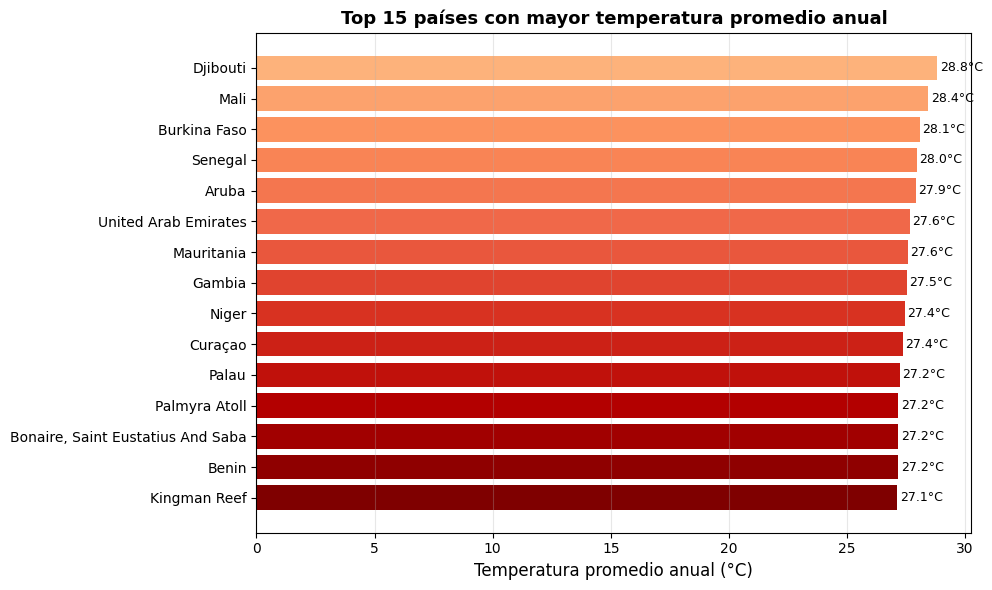

In [167]:
print("Top 15 países más cálidos (promedio histórico)")

query3 = """
SELECT
    pais,
    ROUND(AVG(temp_promedio_anual), 2)  AS temp_historica_promedio,
    COUNT(anio)                          AS anios_con_datos
FROM temp_anual
GROUP BY pais
HAVING anios_con_datos >= 50
ORDER BY temp_historica_promedio DESC
LIMIT 15
"""

resultado3 = pd.read_sql_query(query3, conn)
print(resultado3.to_string(index=False))

#Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
colores = plt.cm.OrRd(np.linspace(0.4, 1.0, len(resultado3)))
bars = ax.barh(resultado3['pais'], resultado3['temp_historica_promedio'], color=colores)
ax.set_xlabel('Temperatura promedio anual (°C)', fontsize=12)
ax.set_title('Top 15 países con mayor temperatura promedio anual', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, resultado3['temp_historica_promedio']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}°C', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('grafico_paises_calidos.png', dpi=150, bbox_inches='tight')
plt.show()

## Pregunta 2 — ¿Qué países muestran mayor variación de temperatura?
Se calcula la diferencia entre la temperatura máxima y mínima anual registrada por país,
lo que indica qué tan extremo es su clima a lo largo del tiempo.

Países con mayor variación de temperatura
         pais  rango_temp  temp_max  temp_min  anios_con_datos
       Canada       23.41      0.79    -22.62              216
       Russia       19.71     -1.63    -21.34              202
   Kazakhstan       17.73      8.94     -8.79              202
North America       17.63      6.44    -11.19              215
       Kuwait       15.62     27.64     12.02              175
   Uzbekistan       15.34     16.19      0.85              185
United States       15.01     12.23     -2.78              215
 Turkmenistan       14.92     18.61      3.69              186
      Algeria       14.87     25.22     10.34              227
       Jordan       14.37     22.23      7.86              205
      Finland       13.14      4.06     -9.08              267
   Gaza Strip       12.86     21.90      9.04              206
       Israel       12.60     22.31      9.71              205
      Ukraine       12.53     10.91     -1.62              267
      Estonia

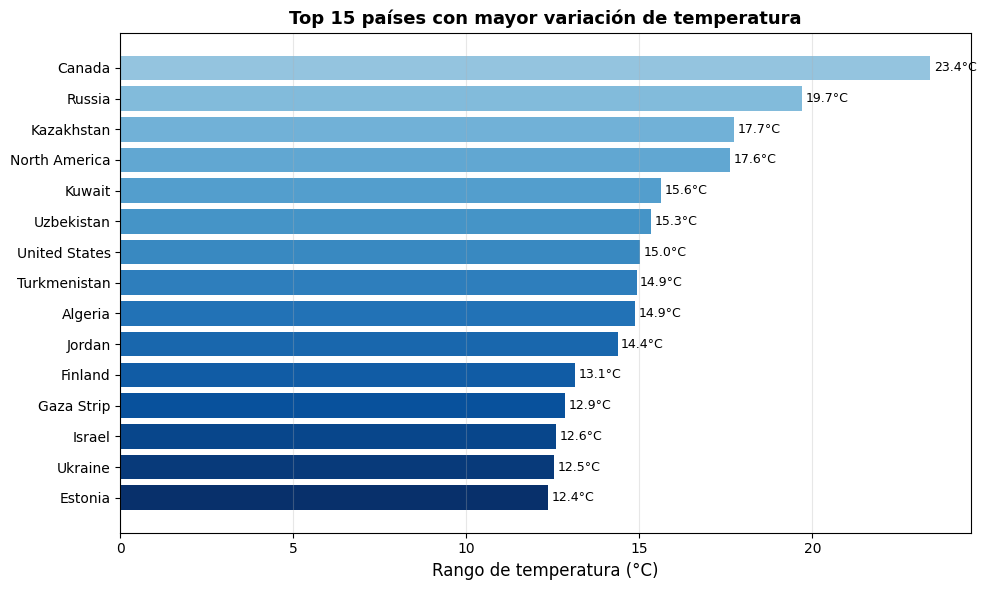

Gráfico guardado


In [168]:
print("Países con mayor variación de temperatura")

query4 = """
SELECT
    pais,
    ROUND(MAX(temp_promedio_anual) - MIN(temp_promedio_anual), 2)   AS rango_temp,
    ROUND(MAX(temp_promedio_anual), 2)                               AS temp_max,
    ROUND(MIN(temp_promedio_anual), 2)                               AS temp_min,
    COUNT(anio)                                                       AS anios_con_datos
FROM temp_anual
GROUP BY pais
HAVING anios_con_datos >= 50
ORDER BY rango_temp DESC
LIMIT 15
"""

resultado4 = pd.read_sql_query(query4, conn)
print(resultado4.to_string(index=False))

#Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
colores2 = plt.cm.Blues(np.linspace(0.4, 1.0, len(resultado4)))
bars2 = ax.barh(resultado4['pais'], resultado4['rango_temp'], color=colores2)
ax.set_xlabel('Rango de temperatura (°C)', fontsize=12)
ax.set_title('Top 15 países con mayor variación de temperatura', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars2, resultado4['rango_temp']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}°C', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('grafico_variacion_temp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado")

## Pregunta 3 — ¿Qué tan completa es la información por país y por año?
Se evalúa la completitud antes del JOIN sobre temp_anual, analizando cuántos años
reporta cada país y cuántos países reportan en cada año.

In [169]:
#Completitud por país y por año (sobre temp_anual)

query_p3_pais = """
SELECT
    pais,
    COUNT(anio)                                                          AS anios_con_datos,
    ROUND(COUNT(anio) * 100.0 / (MAX(anio) - MIN(anio) + 1), 1)        AS pct_completitud
FROM temp_anual
GROUP BY pais
ORDER BY pct_completitud ASC
LIMIT 15
"""
df_p3_pais = pd.read_sql_query(query_p3_pais, conn)
df_p3_pais

,pais,anios_con_datos,pct_completitud
0,Mauritius,142,62.6
1,Reunion,142,62.6
2,Comoros,150,66.1
3,Madagascar,150,66.1
4,Mayotte,150,66.1
5,Seychelles,150,66.1
6,Niger,150,76.9
7,Bahamas,211,82.4
8,Tanzania,136,82.9
9,Christmas Island,159,84.1


In [170]:
query_p3_anio = """
SELECT
    anio,
    COUNT(DISTINCT pais) AS paises_con_datos
FROM temp_anual
GROUP BY anio
ORDER BY anio
"""
df_p3_anio = pd.read_sql_query(query_p3_anio, conn)
df_p3_anio

,anio,paises_con_datos
0,1743,50
1,1744,50
2,1745,50
3,1750,50
4,1751,50
...,...,...
262,2009,242
263,2010,242
264,2011,242
265,2012,242


## Parte abierta — Indicadores: Población y Bosques (Banco Mundial)
Se integran dos indicadores del Banco Mundial:
- Población total por país (SP.POP.TOTL)
- Cobertura de bosques en km² (AG.LND.FRST.K2)

---


Ambas tablas vienen en formato ancho y se transforman a formato largo
antes de integrarse con la base de temperatura.

In [171]:
nombre_pop = '/content/drive/MyDrive/API_SP.POP.TOTL_DS2_en_csv_v2_127039.csv'
print(f" Archivo recibido: {nombre_pop}")

 Archivo recibido: /content/drive/MyDrive/API_SP.POP.TOTL_DS2_en_csv_v2_127039.csv


In [172]:
#Archivo población
df_pop_raw = pd.read_csv(nombre_pop, skiprows=4)
print(f"   Dimensiones: {df_pop_raw.shape}")
print(f"\n Primeras columnas: {list(df_pop_raw.columns[:8])}")
df_pop_raw.head(3)

   Dimensiones: (266, 71)

 Primeras columnas: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963']


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,NaN,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,NaN,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN,NaN


In [173]:
#Pivoteo: formato ancho → formato largo

print("PIVOTEO: Formato ancho → Formato largo")

id_vars = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
year_cols = [col for col in df_pop_raw.columns if str(col).isdigit() and len(str(col)) == 4]

print(f"Años disponibles: {year_cols[0]} — {year_cols[-1]}")

df_pop_long = df_pop_raw[id_vars + year_cols].melt(
    id_vars=id_vars,
    value_vars=year_cols,
    var_name='Year',
    value_name='Value'
)

df_pop_long['Year']  = df_pop_long['Year'].astype(int)
df_pop_long['Value'] = pd.to_numeric(df_pop_long['Value'], errors='coerce')

df_pop_long = df_pop_long.rename(columns={
    'Country Name'  : 'Country',
    'Country Code'  : 'Country_Code',
    'Indicator Name': 'Indicator_Name',
    'Indicator Code': 'Indicator_Code'
})

df_pop_long = df_pop_long.dropna(subset=['Value'])

print(f"Registros con valor: {len(df_pop_long):,}")
df_pop_long.head(8)

PIVOTEO: Formato ancho → Formato largo
Años disponibles: 1960 — 2025
Registros con valor: 17,195


,Country,Country_Code,Indicator_Name,Indicator_Code,Year,Value
0,Aruba,ABW,"Population, total",SP.POP.TOTL,1960,54922.0
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,1960,130075728.0
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,1960,9035043.0
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,1960,97630925.0
4,Angola,AGO,"Population, total",SP.POP.TOTL,1960,5231654.0
5,Albania,ALB,"Population, total",SP.POP.TOTL,1960,1608800.0
6,Andorra,AND,"Population, total",SP.POP.TOTL,1960,9510.0
7,Arab World,ARB,"Population, total",SP.POP.TOTL,1960,91540853.0


In [174]:
#Tabla de Población en SQLite
df_pop_long.to_sql('poblacion', conn, if_exists='replace', index=False)

verificacion = pd.read_sql_query("SELECT COUNT(*) AS total FROM poblacion", conn)
print(f"Tabla 'poblacion' cargada en SQLite")
print(f"Registros: {verificacion['total'][0]:,}")

Tabla 'poblacion' cargada en SQLite
Registros: 17,195


In [175]:
#Verificar correspondencia antes del JOIN
paises_temp = set(df_anual['pais'].unique())
paises_pop  = set(df_pop_long['Country'].unique())

con_match       = paises_temp & paises_pop
sin_match_temp  = paises_temp - paises_pop

print(f" Países en temperatura          : {len(paises_temp)}")
print(f" Países en población            : {len(paises_pop)}")
print(f" Países con correspondencia      : {len(con_match)}")
print(f" En temperatura pero NO en población  : {len(sin_match_temp)}")
print(f"\n Ejemplos sin match (que no se encontraron correspondencia):")
print(sorted(list(sin_match_temp))[:10])

 Países en temperatura          : 242
 Países en población            : 265
 Países con correspondencia      : 163
 En temperatura pero NO en población  : 79

 Ejemplos sin match (que no se encontraron correspondencia):
['Africa', 'Anguilla', 'Antigua And Barbuda', 'Asia', 'Bahamas', 'Baker Island', 'Bonaire, Saint Eustatius And Saba', 'Bosnia And Herzegovina', 'Burma', 'Cape Verde']


In [176]:
#Archivo bosques
nombre_bosques = '/content/drive/MyDrive/API_AG.LND.FRST.K2_DS2_en_csv_v2_710.csv'

df_bosques_raw = pd.read_csv(nombre_bosques, skiprows=4)
print(f"Dimensiones: {df_bosques_raw.shape}")
df_bosques_raw.head(3)

Dimensiones: (266, 71)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Forest area (sq. km),AG.LND.FRST.K2,NaN,NaN,NaN,NaN,NaN,NaN,...,4.2,4.20,4.2,4.2,4.200,4.200,4.2,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Forest area (sq. km),AG.LND.FRST.K2,NaN,NaN,NaN,NaN,NaN,NaN,...,4575901.2,4544314.78,4511676.2,4479395.0,4446875.546,4414514.929,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Forest area (sq. km),AG.LND.FRST.K2,NaN,NaN,NaN,NaN,NaN,NaN,...,12084.4,12084.40,12084.4,12084.4,12084.400,12084.400,12084.4,NaN,NaN,NaN


In [177]:
#Pivoteo bosques: formato ancho → formato largo
id_vars = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
year_cols = [col for col in df_bosques_raw.columns if str(col).isdigit() and len(str(col)) == 4]

df_bosques_long = df_bosques_raw[id_vars + year_cols].melt(
    id_vars=id_vars,
    value_vars=year_cols,
    var_name='Year',
    value_name='Value'
)

df_bosques_long['Year']  = df_bosques_long['Year'].astype(int)
df_bosques_long['Value'] = pd.to_numeric(df_bosques_long['Value'], errors='coerce')

df_bosques_long = df_bosques_long.rename(columns={
    'Country Name'  : 'Country',
    'Country Code'  : 'Country_Code',
    'Indicator Name': 'Indicator_Name',
    'Indicator Code': 'Indicator_Code'
})

df_bosques_long = df_bosques_long.dropna(subset=['Value'])

print(f" Pivoteo completado: {len(df_bosques_long):,} registros")
df_bosques_long.head()

 Pivoteo completado: 8,625 registros


,Country,Country_Code,Indicator_Name,Indicator_Code,Year,Value
7980,Aruba,ABW,Forest area (sq. km),AG.LND.FRST.K2,1990,4.2
7981,Africa Eastern and Southern,AFE,Forest area (sq. km),AG.LND.FRST.K2,1990,4767936.8
7982,Afghanistan,AFG,Forest area (sq. km),AG.LND.FRST.K2,1990,12084.4
7983,Africa Western and Central,AFW,Forest area (sq. km),AG.LND.FRST.K2,1990,2060349.0
7984,Angola,AGO,Forest area (sq. km),AG.LND.FRST.K2,1990,792627.8


In [178]:
#Cargar bosques en SQLite
df_bosques_long.to_sql('bosques', conn, if_exists='replace', index=False)

verificacion = pd.read_sql_query("SELECT COUNT(*) AS total FROM bosques", conn)
print(f" Tabla 'bosques' cargada: {verificacion['total'][0]:,} registros")

 Tabla 'bosques' cargada: 8,625 registros


## Integración de fuentes — JOIN temperatura + población + bosques
Se realiza un INNER JOIN entre temp_anual y poblacion usando país y año
como llaves, y un LEFT JOIN con bosques para no perder países que no
tengan datos forestales. Solo quedan los registros donde temperatura y
población tienen datos, generando la tabla_final con 163 países para
el periodo 1960–2013.


In [179]:
#JOIN entre temperatura, población Y bosques
query_join = """
SELECT
    t.pais,
    t.anio,
    t.temp_promedio_anual,
    t.temp_minima_anual,
    t.temp_maxima_anual,
    t.incertidumbre_promedio,
    p.Value AS poblacion,
    b.Value AS bosques_km2
FROM temp_anual t
INNER JOIN poblacion p
    ON  t.pais = p.Country
    AND t.anio = p.Year
LEFT JOIN bosques b
    ON  t.pais = b.Country
    AND t.anio = b.Year
WHERE p.Value IS NOT NULL
ORDER BY t.pais, t.anio
"""

df_final = pd.read_sql_query(query_join, conn)
df_final.to_sql('tabla_final', conn, if_exists='replace', index=False)

print(f"tabla_final actualizada con población y bosques")
print(f"Registros : {len(df_final):,}")
print(f"Países    : {df_final['pais'].nunique()}")
df_final.head()

tabla_final actualizada con población y bosques
Registros : 8,802
Países    : 163


,pais,anio,temp_promedio_anual,temp_minima_anual,temp_maxima_anual,incertidumbre_promedio,poblacion,bosques_km2
0,Afghanistan,1960,13.985,1.811,26.600,0.442,9035043.0,NaN
1,Afghanistan,1961,14.065,1.482,27.363,0.398,9214083.0,NaN
2,Afghanistan,1962,13.769,0.616,26.961,0.406,9404406.0,NaN
3,Afghanistan,1963,15.033,2.500,27.246,0.401,9604487.0,NaN
4,Afghanistan,1964,13.085,-4.254,26.470,0.449,9814318.0,NaN


## Análisis guiado — Preguntas sobre la tabla final
Las siguientes preguntas se responden sobre tabla_final, resultado de la integración
entre temperatura y población para el periodo 1960–2013.

## Pregunta 1 — ¿Qué países tienen las mayores temperaturas promedio anuales?

Países más cálidos:
                    pais  temp_promedio_historica
0               Djibouti                    29.18
1                   Mali                    28.90
2           Burkina Faso                    28.51
3                Senegal                    28.44
4                  Aruba                    28.40
5   United Arab Emirates                    28.23
6             Mauritania                    28.11
7                  Niger                    27.86
8                  Palau                    27.59
9                  Benin                    27.55
10                  Chad                    27.48
11                 Sudan                    27.46
12             Sri Lanka                    27.44
13                 Qatar                    27.36
14                  Oman                    27.36


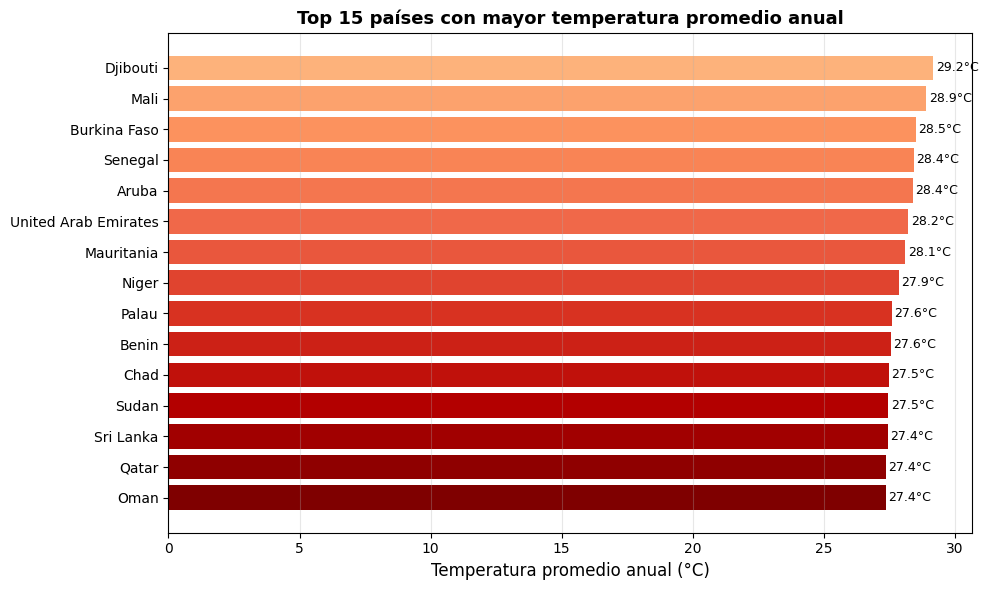

In [180]:
#Países con mayores temperaturas promedio anuales
query_p1 = """
SELECT
    pais,
    ROUND(AVG(temp_promedio_anual), 2) AS temp_promedio_historica
FROM tabla_final
GROUP BY pais
ORDER BY temp_promedio_historica DESC
LIMIT 15
"""
df_p1 = pd.read_sql_query(query_p1, conn)
print("Países más cálidos:")
print(df_p1)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
colores = plt.cm.OrRd(np.linspace(0.4, 1.0, len(df_p1)))
bars = ax.barh(df_p1['pais'], df_p1['temp_promedio_historica'], color=colores)
ax.set_xlabel('Temperatura promedio anual (°C)', fontsize=12)
ax.set_title('Top 15 países con mayor temperatura promedio anual', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, df_p1['temp_promedio_historica']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}°C', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación Gráfico:**

El gráfico muestra los 15 países con mayor temperatura promedio
anual en el periodo 1960–2013. Djibouti encabeza la lista con
29.2°C, seguido de Mali y Burkina Faso, todos ubicados en África
occidental, una región caracterizada por climas desérticos y
tropicales extremos.

Comparando con la exploración previa sobre la base completa
(1743–2013), se observan dos diferencias principales:

La primera es que las temperaturas son ligeramente más altas en
la tabla final. Por ejemplo Djibouti pasa de 28.8°C a 29.2°C.
Esto tiene sentido porque el periodo 1960–2013 es más reciente
y concentra los años más cálidos producto del calentamiento global.

La segunda es que algunos países cambian. En la exploración previa
aparecían territorios pequeños como Palmyra Atoll, Kingman Reef y
Bonaire, que al no tener datos de población fueron excluidos del
JOIN. En su lugar entran Chad, Sudan, Sri Lanka, Qatar y Oman,
que sí tienen correspondencia en el Banco Mundial.

En ambos casos el patrón geográfico se mantiene: los países más
cálidos del mundo se concentran en África y Medio Oriente.

## Pregunta 2 — ¿Qué países muestran mayor variación de temperatura?

In [181]:
#Países con mayor variación de temperatura

query_p2 = """
SELECT
    pais,
    ROUND(MAX(temp_promedio_anual) - MIN(temp_promedio_anual), 2) AS variacion_temp
FROM tabla_final
GROUP BY pais
ORDER BY variacion_temp DESC
LIMIT 15
"""
df_p2 = pd.read_sql_query(query_p2, conn)
print("Mayor variación de temperatura:")
df_p2

Mayor variación de temperatura:


,pais,variacion_temp
0,Uzbekistan,5.25
1,Kazakhstan,5.21
2,Turkmenistan,5.19
3,Canada,5.16
4,Greenland,5.04
5,Denmark,4.93
6,Ukraine,4.73
7,Finland,4.55
8,Mongolia,4.40
9,Moldova,4.24


**Nota:** La variación en la tabla_final (máximo ~5°C) es menor que en
la exploración previa sobre temp_anual (máximo ~23°C) porque la
tabla_final cubre solo el periodo 1960–2013 (54 años), mientras que
temp_anual abarca desde 1743. Un periodo más corto naturalmente
muestra menos variación acumulada.

## Pregunta 3 - ¿Qué tan completa es la información por país y por año?

In [182]:
#Por país
query_p3_pais = """
SELECT
    pais,
    COUNT(*)                             AS total_registros,
    ROUND(COUNT(*) * 100.0 / 54, 1)     AS pct_completitud
FROM tabla_final
GROUP BY pais
ORDER BY total_registros ASC
"""
df_p3_pais = pd.read_sql_query(query_p3_pais, conn)
print(f"Países en tabla final: {len(df_p3_pais)}")
df_p3_pais.head(15)

Países en tabla final: 163


,pais,total_registros,pct_completitud
0,Afghanistan,54,100.0
1,Albania,54,100.0
2,Algeria,54,100.0
3,American Samoa,54,100.0
4,Andorra,54,100.0
5,Angola,54,100.0
6,Argentina,54,100.0
7,Armenia,54,100.0
8,Aruba,54,100.0
9,Australia,54,100.0


In [183]:
#Por año
query_p3_anio = """
SELECT
    anio,
    COUNT(DISTINCT pais) AS paises_con_datos,
    ROUND(COUNT(DISTINCT pais) * 100.0 / 163, 1) AS pct_completitud
FROM tabla_final
GROUP BY anio
ORDER BY anio
"""
df_p3_anio = pd.read_sql_query(query_p3_anio, conn)
print("Completitud por año:")
df_p3_anio.head(15)

Completitud por año:


,anio,paises_con_datos,pct_completitud
0,1960,163,100.0
1,1961,163,100.0
2,1962,163,100.0
3,1963,163,100.0
4,1964,163,100.0
5,1965,163,100.0
6,1966,163,100.0
7,1967,163,100.0
8,1968,163,100.0
9,1969,163,100.0


Observación: Cantidad de países que se perdieron en el JOIN

In [184]:
#Cantidad de países que se perdieron en el JOIN
query_perdidos = """
SELECT COUNT(DISTINCT pais) AS paises_perdidos
FROM temp_anual
WHERE pais NOT IN (SELECT DISTINCT pais FROM tabla_final)
"""

df_perdidos = pd.read_sql_query(query_perdidos, conn)
print("Países perdidos en el JOIN:")
df_perdidos

Países perdidos en el JOIN:


,paises_perdidos
0,79


In [185]:
#¿Cuáles paises?
faltantes = paises_temp - paises_wb
print(f"Países perdidos en el JOIN: {len(faltantes)}")
print(list(faltantes))

Países perdidos en el JOIN: 79
['Western Sahara', 'Svalbard And Jan Mayen', 'Christmas Island', 'North Korea', 'Kingman Reef', 'Vietnam', 'Denmark (Europe)', 'Turks And Caicas Islands', 'Bonaire, Saint Eustatius And Saba', 'Gambia', 'Mayotte', 'Sint Maarten', 'Federated States Of Micronesia', 'Oceania', 'Palestina', 'South Georgia And The South Sandwich Isla', 'Swaziland', 'Africa', 'Niue', 'Macau', 'Isle Of Man', 'Turkey', 'Czech Republic', 'Bosnia And Herzegovina', 'Europe', 'Gaza Strip', 'Guinea Bissau', 'Falkland Islands (Islas Malvinas)', 'Curaçao', 'Anguilla', 'Somalia', 'Burma', 'Saint Vincent And The Grenadines', 'Asia', 'Iran', 'Cape Verde', 'Saint Martin', 'Saint Lucia', 'Timor Leste', 'French Guiana', 'Heard Island And Mcdonald Islands', 'Martinique', 'Kyrgyzstan', 'Baker Island', 'French Southern And Antarctic Lands', 'South Korea', 'Åland', 'Egypt', 'Virgin Islands', 'Bahamas', 'Reunion', 'Saint Barthélemy', 'Montserrat', 'South America', 'Saint Kitts And Nevis', 'Sao Tome

**Interpretación:** Todos los países muestran 54 registros y 100% de
completitud, y todos los años muestran exactamente 163 países. Esto
ocurre porque el INNER JOIN solo conservó las combinaciones donde
ambas fuentes tenían datos completos. La verdadera pérdida de
información está en los 79 países que quedaron excluidos por no tener
correspondencia de nombres entre la base de temperatura y el Banco
Mundial, lo que representa una reducción del 32.6% respecto a los
242 países originales.

## Pregunta 4 - ¿Existen diferencias visibles entre países al comparar temperatura con el indicador seleccionado de la API?
Se compara la temperatura promedio histórica con la población promedio por país mediante
un gráfico de dispersión, buscando patrones descriptivos entre ambas variables.

In [186]:
#Diferencias visibles entre países: temperatura vs población
query_p4 = """
SELECT
    pais,
    ROUND(AVG(temp_promedio_anual), 2)      AS temp_promedio,
    ROUND(AVG(poblacion) / 1000000, 1)      AS poblacion_promedio_millones
FROM tabla_final
GROUP BY pais
ORDER BY pais
"""
df_p4 = pd.read_sql_query(query_p4, conn)
print("Temperatura vs Población (todos los países):")
df_p4

Temperatura vs Población (todos los países):


,pais,temp_promedio,poblacion_promedio_millones
0,Afghanistan,14.62,15.9
1,Albania,13.07,2.7
2,Algeria,23.59,23.3
3,American Samoa,26.96,0.0
4,Andorra,11.75,0.0
...,...,...,...
158,United States,9.18,246.0
159,Uruguay,17.68,3.0
160,Uzbekistan,13.13,18.8
161,Zambia,21.64,7.7


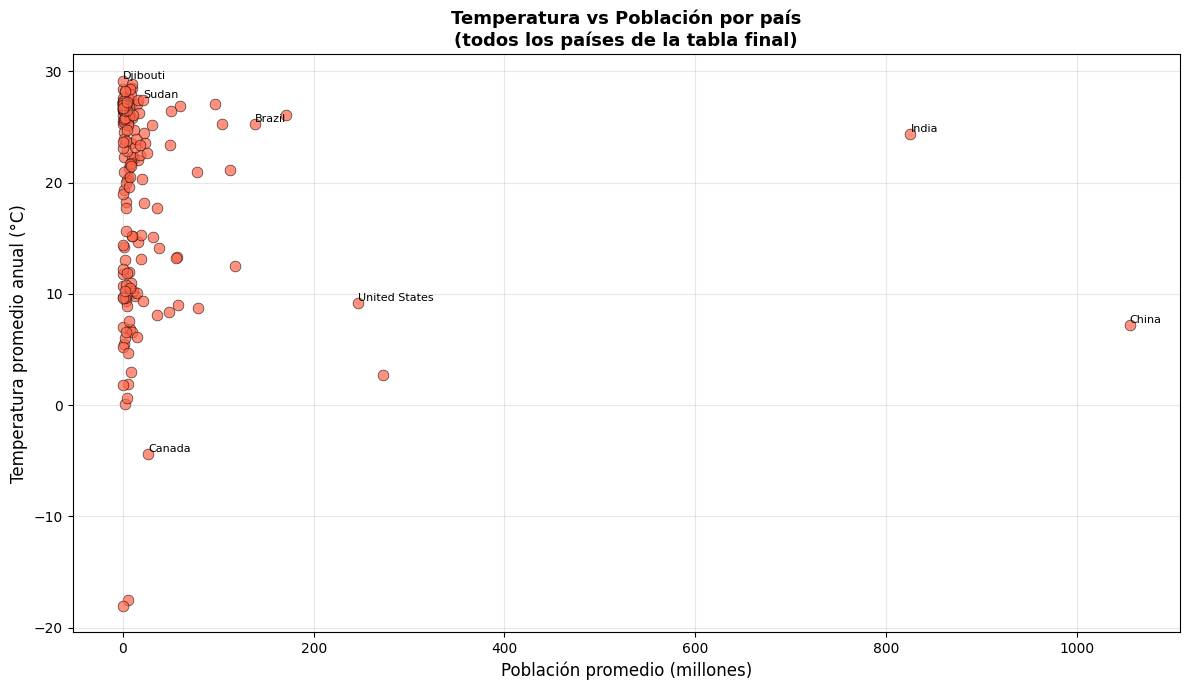

In [187]:
#Gráfico Pregunta 4
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(df_p4['poblacion_promedio_millones'], df_p4['temp_promedio'],
           color='tomato', s=60, edgecolors='black', linewidth=0.5, alpha=0.7)

#Etiquetar solo los más relevantes para no saturar
paises_etiquetar = ['China', 'India', 'United States', 'Brazil',
                    'Djibouti', 'Canada', 'Russia', 'Sudan']
for _, row in df_p4[df_p4['pais'].isin(paises_etiquetar)].iterrows():
    ax.annotate(row['pais'],
                (row['poblacion_promedio_millones'], row['temp_promedio']),
                fontsize=8, ha='left', va='bottom')

ax.set_xlabel('Población promedio (millones)', fontsize=12)
ax.set_ylabel('Temperatura promedio anual (°C)', fontsize=12)
ax.set_title('Temperatura vs Población por país\n(todos los países de la tabla final)',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación:** El gráfico muestra todos los países de la tabla
final. Se observa que los países más cálidos (por encima de 25°C)
corresponden a naciones africanas y de Medio Oriente con poblaciones
relativamente pequeñas. Los países más poblados como China, India y
Estados Unidos tienen temperaturas intermedias. No se observa una
relación directa entre población y temperatura, lo que sugiere que
la temperatura depende más de la ubicación geográfica que del tamaño
poblacional.

## Pregunta 5 - ¿Qué limitaciones se observan en la integración de ambas fuentes?
Se cuantifica la pérdida de información generada por el JOIN y se identifican las
principales limitaciones metodológicas del proceso de integración.

In [188]:
#Limitaciones de la integración
query_p5 = """
SELECT
    'Países en temperatura'             AS fuente,
    COUNT(DISTINCT pais)                AS total
FROM temp_anual

UNION ALL

SELECT
    'Países en población',
    COUNT(DISTINCT Country)
FROM poblacion

UNION ALL

SELECT
    'Países en tabla final (JOIN)',
    COUNT(DISTINCT pais)
FROM tabla_final
"""
df_p5 = pd.read_sql_query(query_p5, conn)
print("Países perdidos en la integración:")
df_p5

Países perdidos en la integración:


,fuente,total
0,Países en temperatura,242
1,Países en población,265
2,Países en tabla final (JOIN),163


**Esto evidencia las siguientes limitaciones:**
1. Nombres de países no estandarizados entre ambas fuentes, lo que
   impidió que 79 países de temperatura encontraran correspondencia.

2. Cobertura temporal asimétrica: la temperatura tiene datos desde 1743
   pero la población solo desde 1960, reduciendo el análisis a 54 años.

3. La agregación de datos mensuales a anuales puede ocultar variaciones
   estacionales importantes.

4. Los valores nulos eliminados en la limpieza (5.65% de la temperatura)
   pueden afectar la representatividad de algunos países.

## Componente abierto — ¿Ha aumentado la temperatura promedio global con el tiempo?
Pregunta propia de análisis: se estudia la evolución de la temperatura promedio global
entre 1960 y 2013 para identificar si existe una tendencia de calentamiento visible en los datos.

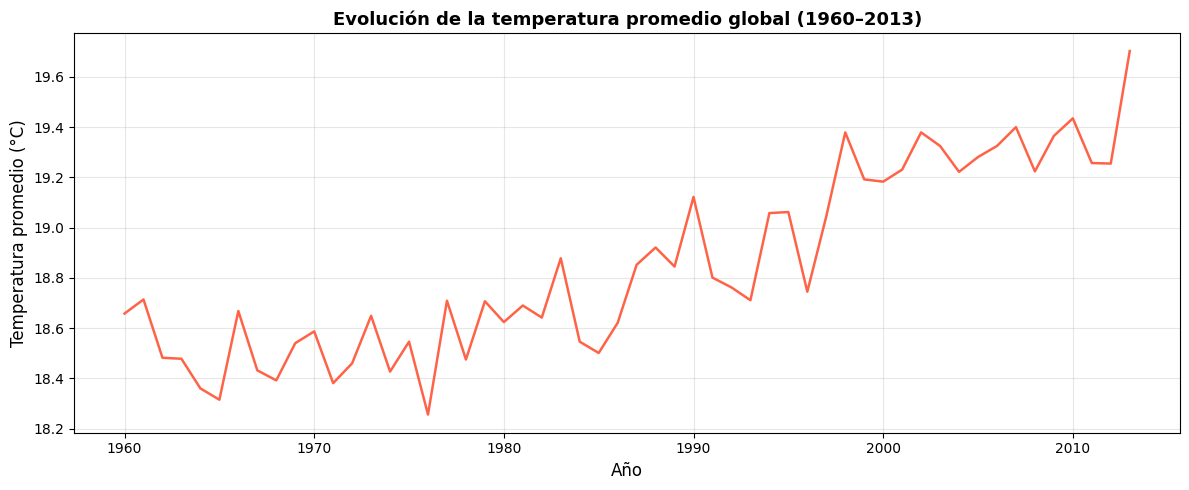

In [189]:
#Aumento temperatura
query_abierto = """
SELECT
    anio,
    ROUND(AVG(temp_promedio_anual), 3) AS temp_global_promedio
FROM tabla_final
WHERE anio BETWEEN 1960 AND 2013
GROUP BY anio
ORDER BY anio
"""
df_abierto = pd.read_sql_query(query_abierto, conn)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_abierto['anio'], df_abierto['temp_global_promedio'],
        color='tomato', linewidth=1.8)
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Temperatura promedio (°C)', fontsize=12)
ax.set_title('Evolución de la temperatura promedio global (1960–2013)',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretación — Componente abierto

El gráfico muestra la evolución de la temperatura promedio global
entre 1960 y 2013. Se identifican los siguientes hallazgos:

1. Tendencia al alza: la temperatura promedio pasó de aproximadamente
   18.5°C en 1960 a cerca de 19.6°C en 2013, un aumento de más de
   1°C en 54 años.

2. Aceleración del calentamiento: antes de 1980 la temperatura
   oscilaba entre 18.3°C y 18.8°C. A partir de 1980 se observa
   una tendencia ascendente más sostenida y pronunciada.

3. Variaciones anuales: aunque la tendencia es creciente, existen
   fluctuaciones año a año normales en el sistema climático.

4. Periodo más cálido: los años 2000–2013 concentran las temperaturas
   más altas del periodo analizado, siendo 2013 el año con mayor
   temperatura registrada (~19.7°C).

Este resultado es consistente con los reportes científicos sobre
cambio climático global, aunque este análisis es puramente descriptivo
y no permite establecer relaciones causales.

## Conclusiones
El análisis permitió identificar que los países más cálidos se concentran en zonas
tropicales, mientras que los de mayor variación corresponden a regiones con climas
extremos. La integración con el indicador de población redujo la cobertura temporal
al periodo 1960–2013 y excluyó países sin correspondencia de nombres entre fuentes.
Se observa una tendencia de calentamiento global en el periodo analizado.

## Trabajo futuro y mejoras posibles - comentario personal

A lo largo del desarrollo de este trabajo identifiqué varias
oportunidades de mejora que, por el alcance del ejercicio, no fueron
implementadas pero que considero importantes para un análisis más
profundo.

Una de las principales limitaciones que encontré fue la pérdida de
79 países en el JOIN por diferencias en los nombres entre fuentes.
También podría estandarizar esos nombres manualmente para
recuperar esos países y obtener resultados más representativos a nivel
global.

También me parece relevante que el indicador de bosques solo reporta
datos cada 5 años, lo que genera muchos valores nulos en los años
intermedios. Una mejora natural sería aplicar interpolación lineal
para estimar esos valores faltantes y así aprovechar mejor esa
variable en el análisis.

En cuanto al componente abierto, el gráfico muestra claramente una
tendencia al alza en la temperatura, pero me gustaría ir más allá
de lo visual e implementar una regresión lineal para cuantificar
exactamente cuántos grados aumenta la temperatura por década y
determinar si esa tendencia es estadísticamente significativa.

Finalmente, creo que el análisis ganaría mucho con la incorporación
de más indicadores del Banco Mundial como emisiones de CO2, consumo
de energía y agricultura, que también están relacionados con el cambio
climático y permitirían explorar correlaciones más completas entre
variables.